# AutoValue: vehicle price workflow
Run cells manually. The project uses one merged dataset and one saved prediction model. Prices are in LKR lakhs.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().resolve()
if not (ROOT / 'train.py').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import train
from backend.features import FEATURES, VehicleFeatures
from backend.predict import load_bundle, predict_car


## 1. Merge and prepare
This cell regenerates data/cars.csv from the two inputs. Supplied mileage is retained. Tiptronic is represented as Automatic.


In [2]:
data = train.merge_data()
display(data.head())
print(data.shape)
display(data.isna().sum())
display(data.describe(include='all'))


Merged 12,040 input rows into 11,750 records.


,Brand,Model,YOM,Engine (cc),Gear,Fuel Type,Millage(KM),Condition,Price,Date
0,AUDI,A1,2016.0,990.0,AUTOMATIC,PETROL,99000.0,USED,100.0,2025-02-05
1,AUDI,A1,2017.0,1000.0,AUTOMATIC,PETROL,88000.0,USED,97.0,2025-01-14
2,AUDI,A1,2018.0,1000.0,AUTOMATIC,PETROL,77000.0,USED,98.5,2025-01-23
3,AUDI,A1,2017.0,1000.0,AUTOMATIC,PETROL,88000.0,USED,107.0,2024-12-21
4,AUDI,A1,2017.0,1000.0,AUTOMATIC,PETROL,88000.0,USED,99.5,2024-12-21


(11750, 10)


Brand          0
Model          0
YOM            0
Engine (cc)    0
Gear           0
Fuel Type      0
Millage(KM)    0
Condition      0
Price          0
Date           0
dtype: int64

,Brand,Model,YOM,Engine (cc),Gear,Fuel Type,Millage(KM),Condition,Price,Date
count,11750,11750,11750.000000,11750.000000,11750,11750,11750.000000,11750,11750.000000,11750
unique,56,1698,NaN,NaN,2,3,NaN,2,NaN,88
top,TOYOTA,ALTO,NaN,NaN,AUTOMATIC,PETROL,NaN,USED,NaN,2026-09-26
freq,3743,424,NaN,NaN,8141,9185,NaN,11052,NaN,921
mean,NaN,NaN,2008.966723,1278.142536,NaN,NaN,175555.978043,NaN,71.661073,NaN
std,NaN,NaN,10.788467,475.426465,NaN,NaN,116881.044689,NaN,95.564952,NaN
min,NaN,NaN,1950.000000,200.000000,NaN,NaN,0.000000,NaN,2.650000,NaN
25%,NaN,NaN,2002.000000,1000.000000,NaN,NaN,99000.000000,NaN,28.750000,NaN
50%,NaN,NaN,2011.000000,1300.000000,NaN,NaN,154000.000000,NaN,54.000000,NaN
75%,NaN,NaN,2016.000000,1500.000000,NaN,NaN,242000.000000,NaN,81.540385,NaN


## 2. Exploratory analysis
Inspect missing values, distributions, relationships and extreme prices. Charts are displayed here, not saved as report files.


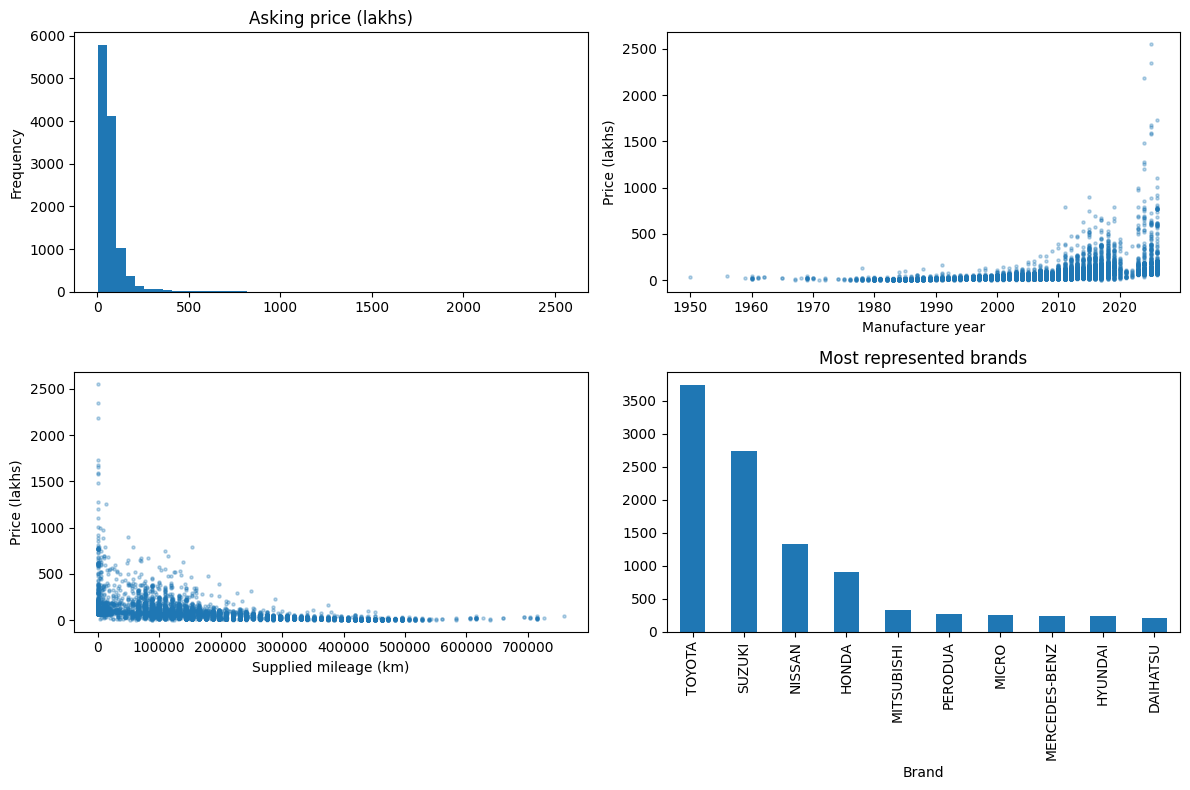

,YOM,Engine (cc),Millage(KM),Price
YOM,1.000000,-0.287513,-0.979158,0.414956
Engine (cc),-0.287513,1.000000,0.278796,0.376610
Millage(KM),-0.979158,0.278796,1.000000,-0.412056
Price,0.414956,0.376610,-0.412056,1.000000


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
data.Price.plot.hist(bins=50, ax=axes[0, 0], title='Asking price (lakhs)')
axes[0, 1].scatter(data.YOM, data.Price, s=5, alpha=.3)
axes[0, 1].set(xlabel='Manufacture year', ylabel='Price (lakhs)')
axes[1, 0].scatter(data['Millage(KM)'], data.Price, s=5, alpha=.3)
axes[1, 0].set(xlabel='Supplied mileage (km)', ylabel='Price (lakhs)')
data.Brand.value_counts().head(10).plot.bar(ax=axes[1, 1], title='Most represented brands')
plt.tight_layout()
plt.show()
display(data[['YOM', 'Engine (cc)', 'Millage(KM)', 'Price']].corr())


## 3. Features
Brand, model, manufacture year, engine capacity, transmission, fuel type, mileage and condition predict Price. Age, brand/model and log mileage are generated inside the pipeline. Date is excluded.


In [4]:
display(VehicleFeatures().fit_transform(data[FEATURES]).head())


,YOM,Brand,Model,Gear,Fuel Type,Condition,Engine (cc),Millage(KM),Age at reference year,Brand model,Log mileage
0,2016.0,AUDI,A1,AUTOMATIC,PETROL,USED,990.0,99000.0,10.0,AUDI | A1,11.502885
1,2017.0,AUDI,A1,AUTOMATIC,PETROL,USED,1000.0,88000.0,9.0,AUDI | A1,11.385103
2,2018.0,AUDI,A1,AUTOMATIC,PETROL,USED,1000.0,77000.0,8.0,AUDI | A1,11.251574
3,2017.0,AUDI,A1,AUTOMATIC,PETROL,USED,1000.0,88000.0,9.0,AUDI | A1,11.385103
4,2017.0,AUDI,A1,AUTOMATIC,PETROL,USED,1000.0,88000.0,9.0,AUDI | A1,11.385103


## 4. Train and compare
This cell retrains candidates using grouped cross-validation, selects by mean validation MAE, evaluates on held-out groups and replaces the single saved model. Run only when ready to retrain.


In [5]:
# Uncomment to train again:
# bundle = train.train_model(data)
bundle = load_bundle()
comparison = pd.DataFrame(bundle['metadata']['metrics']['model_comparison'])
display(comparison[['Model', 'CV MAE']].sort_values('CV MAE'))
display(pd.Series(bundle['metadata']['metrics']['test'], name='Holdout results'))


,Model,CV MAE
5,Extra trees,9.552182
6,Extra trees regularized,9.992847
4,Random forest,10.686259
3,Decision tree,13.774353
7,Gradient boosting,13.863826
1,Linear regression,19.935263
2,Ridge regression,21.444924
0,Median baseline,42.740495


MAE               9.048904
RMSE             49.549483
R2                0.728424
MAPE_pct         13.296415
Within_10_pct    68.148450
Within_20_pct    84.461664
Name: Holdout results, dtype: float64

## 5. Predict
The website uses this same prediction function and saved pipeline.


In [6]:
example = bundle['metadata']['example']
display(example)
display(predict_car(example, bundle))


{'brand': 'NISSAN',
 'model_name': 'ROOX',
 'yom': 2024,
 'engine_cc': 660.0,
 'gear': 'AUTOMATIC',
 'fuel_type': 'HYBRID',
 'millage': 30000.0,
 'condition': 'USED'}

{'predicted_price_lakhs': 88.75,
 'predicted_price_lkr': 8875000.0,
 'currency': 'LKR',
 'model': 'Extra trees',
 'data_period': ['2024-12-03', '2026-09-27'],
 'valuation_basis': 'Vehicle asking-price estimate.',
 'warnings': []}